# 🏠 House Price Prediction — End-to-End ML Pipeline

**Goal:** Predict house sale prices from structural, locational, and
quality features using a full machine learning pipeline.

## What this notebook covers
1. Data loading & overview
2. Exploratory Data Analysis (EDA)
3. Data cleaning (missing values, outliers)
4. Feature engineering & preprocessing pipeline
5. Model training & comparison (Linear, Ridge, Random Forest, Gradient Boosting)
6. Hyperparameter tuning with `GridSearchCV`
7. Final evaluation (RMSE, MAE, R²)
8. Model explainability with **SHAP**
9. Saving the final model for reuse

---


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib
import shap

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

We use a synthetically generated but realistic housing dataset
(`data/housing.csv`) with 1,500 houses and 14 features:
structural details (area, bedrooms, bathrooms), location
(neighborhood, distance to city), quality scores, and amenities.


In [2]:
df = pd.read_csv('../data/housing.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (1500, 15)


,area_sqft,bedrooms,bathrooms,year_built,garage_spaces,lot_size,overall_qual,distance_to_city_km,neighborhood,house_style,heating_type,has_pool,has_basement,central_air,sale_price
0,3242,3,1.5,1967,2,3824.0,8,11.8,Hillside,Single_Family,Gas,0,1,1,465337
1,1534,2,3.0,1966,0,5486.0,9,2.1,Downtown,Single_Family,Oil,0,0,1,358949
2,1651,3,2.0,1989,2,7364.0,5,13.3,Hillside,Single_Family,Gas,0,0,1,365008
3,2567,1,1.0,1998,1,6355.0,9,1.1,Downtown,Single_Family,NaN,1,0,1,570158
4,2373,4,2.5,2006,1,6556.0,8,4.7,Lakeside,Duplex,Electric,1,1,0,329433


In [3]:
df.describe()


,area_sqft,bedrooms,bathrooms,year_built,garage_spaces,lot_size,overall_qual,distance_to_city_km,has_pool,has_basement,central_air,sale_price
count,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1455.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,1842.232000,3.303333,2.31900,1986.392000,1.502667,6936.013746,6.518000,8.222867,0.140000,0.619333,0.805333,275388.968000
std,619.198845,1.181067,0.78474,21.379969,0.868617,2581.117025,1.942556,8.429680,0.347103,0.485713,0.396076,91017.674462
min,400.000000,1.000000,1.00000,1950.000000,0.000000,1000.000000,1.000000,0.500000,0.000000,0.000000,0.000000,70981.000000
25%,1425.750000,3.000000,2.00000,1968.000000,1.000000,5118.000000,5.000000,2.200000,0.000000,0.000000,1.000000,209208.500000
50%,1835.500000,3.000000,2.00000,1987.000000,2.000000,6889.000000,7.000000,5.300000,0.000000,1.000000,1.000000,266430.500000
75%,2212.500000,4.000000,3.00000,2005.000000,2.000000,8748.000000,8.000000,11.525000,0.000000,1.000000,1.000000,331908.750000
max,5424.000000,6.000000,4.00000,2023.000000,3.000000,15823.000000,10.000000,58.500000,1.000000,1.000000,1.000000,874627.000000


In [4]:
# Check data types and missing values
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


area_sqft                int64
bedrooms                 int64
bathrooms              float64
year_built               int64
garage_spaces            int64
lot_size               float64
overall_qual             int64
distance_to_city_km    float64
neighborhood               str
house_style                str
heating_type               str
has_pool                 int64
has_basement             int64
central_air              int64
sale_price               int64
dtype: object

Missing values:
lot_size        45
heating_type    30
dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable: `sale_price`

Let's look at the distribution of house prices. Real-world price
data is often **right-skewed** (a few very expensive houses pull
the mean up).


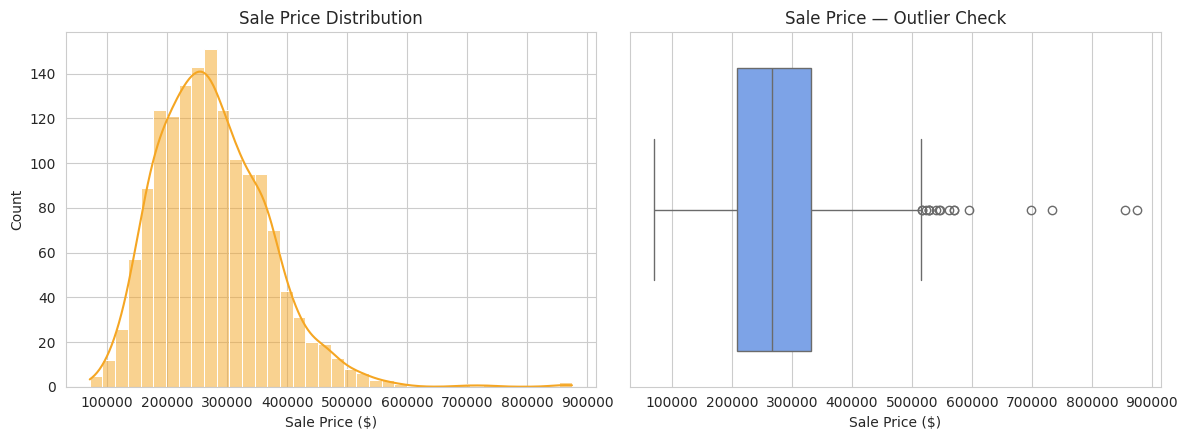

Mean price:   $275,389
Median price: $266,430
Skew:         0.91


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['sale_price'], kde=True, ax=axes[0], color='#f5a623')
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Sale Price ($)')

sns.boxplot(x=df['sale_price'], ax=axes[1], color='#6c9ef8')
axes[1].set_title('Sale Price — Outlier Check')
axes[1].set_xlabel('Sale Price ($)')

plt.tight_layout()
plt.show()

print(f"Mean price:   ${df['sale_price'].mean():,.0f}")
print(f"Median price: ${df['sale_price'].median():,.0f}")
print(f"Skew:         {df['sale_price'].skew():.2f}")


**Observation:** The distribution is right-skewed with a handful of
high-value outliers (luxury houses). This is normal for real estate
data — most models handle this reasonably well, but it's worth
noting when interpreting errors (a $30K error means more for a
$150K house than a $700K house).


### 3.2 Correlation Heatmap

Which numeric features are most strongly related to price?


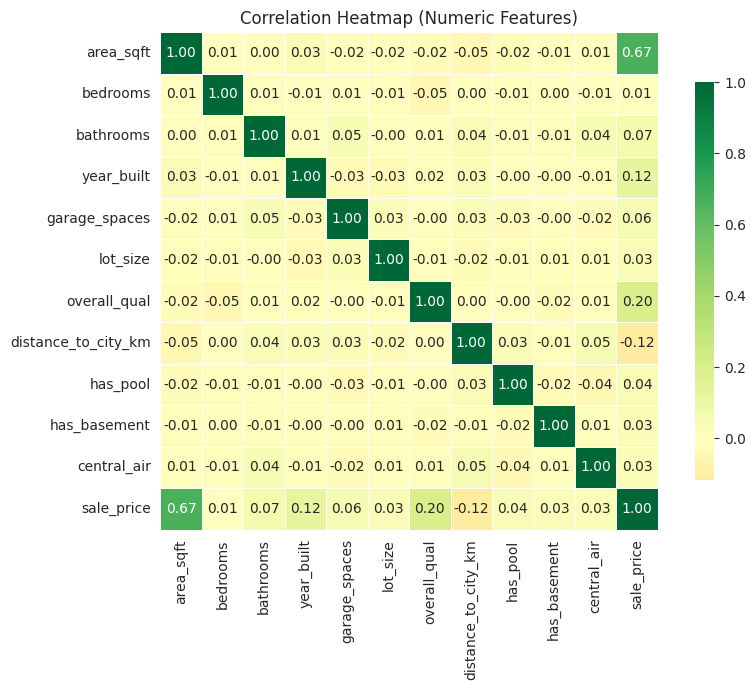

sale_price             1.000000
area_sqft              0.669749
overall_qual           0.198999
year_built             0.120651
bathrooms              0.066455
garage_spaces          0.056381
has_pool               0.035004
lot_size               0.033425
central_air            0.028813
has_basement           0.026624
bedrooms               0.008653
distance_to_city_km   -0.116034
Name: sale_price, dtype: float64

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

corr['sale_price'].sort_values(ascending=False)


**Observation:** `area_sqft` and `overall_qual` (overall quality
score) show the strongest positive correlation with price.
`distance_to_city_km` is negatively correlated — houses further
from the city tend to be cheaper.


### 3.3 Price by Neighborhood

Location matters a lot in real estate. Let's compare price
distributions across neighborhoods.


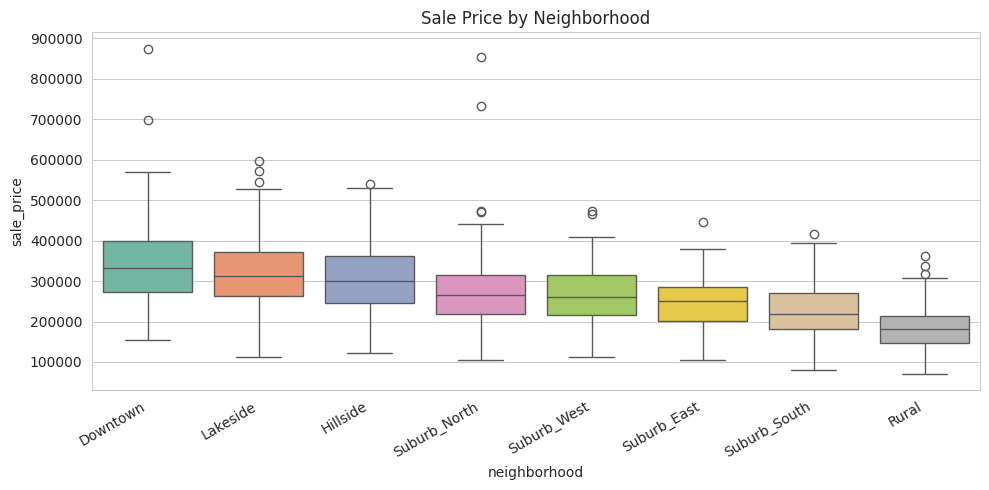

In [7]:
plt.figure(figsize=(10, 5))
order = df.groupby('neighborhood')['sale_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='neighborhood', y='sale_price', order=order, palette='Set2')
plt.title('Sale Price by Neighborhood')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Observation:** `Downtown`, `Lakeside`, and `Hillside` command the
highest median prices, while `Rural` and `Suburb_South` are the
most affordable — consistent with typical real-world location
premiums.


### 3.4 Area vs Price (colored by Quality)


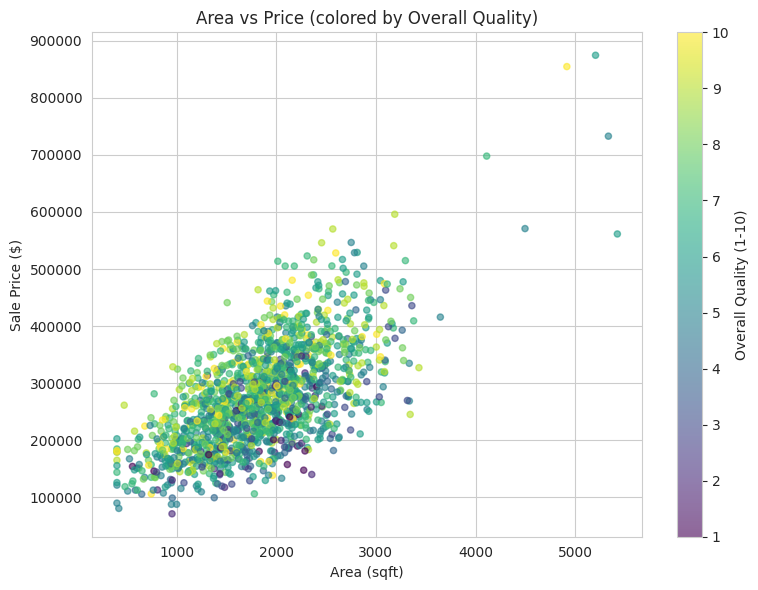

In [8]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['area_sqft'], df['sale_price'],
                       c=df['overall_qual'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Overall Quality (1-10)')
plt.xlabel('Area (sqft)')
plt.ylabel('Sale Price ($)')
plt.title('Area vs Price (colored by Overall Quality)')
plt.tight_layout()
plt.show()


**Observation:** There's a clear positive relationship between area
and price, and houses with higher quality scores (brighter colors)
tend to sit above the general trend line — quality adds value
beyond size alone.


## 4. Train / Test Split

We split the data **before** any preprocessing to avoid data
leakage — the model must never "see" test data during training,
including during imputation or scaling.


In [9]:
X = df.drop(columns=['sale_price'])
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")


Train set: 1200 rows
Test set:  300 rows


## 5. Preprocessing Pipeline

We build a `ColumnTransformer` that applies different preprocessing
to numeric vs categorical columns:

- **Numeric columns** → fill missing values with the median → scale
  with `StandardScaler`
- **Categorical columns** → fill missing values with the most
  frequent category → one-hot encode

Wrapping everything in a `Pipeline` means we can call `.fit()` and
`.predict()` on raw data — preprocessing happens automatically and
identically every time.


In [10]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Numeric features (11): ['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'garage_spaces', 'lot_size', 'overall_qual', 'distance_to_city_km', 'has_pool', 'has_basement', 'central_air']
Categorical features (3): ['neighborhood', 'house_style', 'heating_type']


## 6. Train & Compare Multiple Models

We try four regression models with default-ish settings to get a
baseline sense of which algorithm family fits this data best:

- **Linear Regression** — simple baseline
- **Ridge Regression** — linear model with L2 regularization
- **Random Forest** — ensemble of decision trees (bagging)
- **Gradient Boosting** — ensemble of decision trees (boosting)


In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42),
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df


,Model,RMSE,MAE,R2
1,Ridge Regression,30426.606045,23683.344316,0.883231
0,Linear Regression,30468.825427,23716.196730,0.882907
3,Gradient Boosting,31563.389294,23876.609465,0.874343
2,Random Forest,37671.401311,28804.579444,0.821004


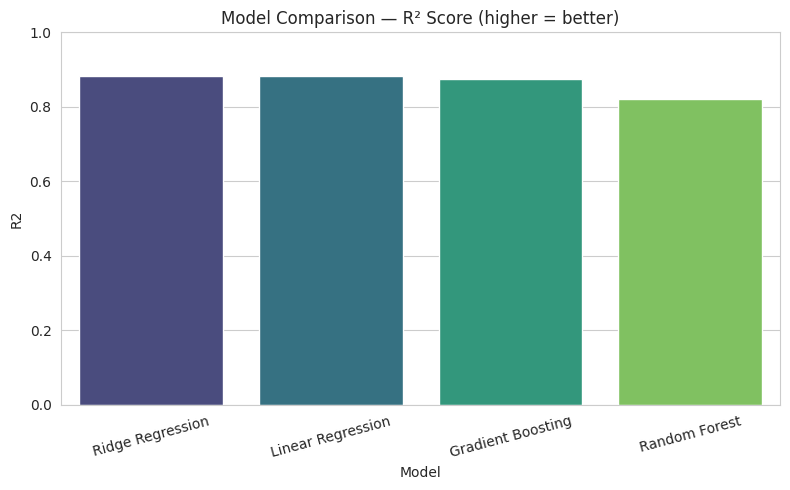

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='R2', palette='viridis')
plt.title('Model Comparison — R² Score (higher = better)')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Observation:** Linear/Ridge regression performs surprisingly well
here because our synthetic price formula is mostly additive and
linear. Gradient Boosting is close behind and typically generalizes
better on real-world data with more complex interactions, so we'll
tune it further below.


## 7. Hyperparameter Tuning with GridSearchCV

`GridSearchCV` exhaustively tries every combination of the
parameters we specify, using 5-fold cross-validation, and keeps the
combination with the best average R² score.

We tune **Gradient Boosting**:
- `n_estimators`: number of trees
- `learning_rate`: how much each tree corrects the previous one
- `max_depth`: how deep each tree can grow (controls overfitting)


In [13]:
tuning_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators':  [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth':     [2, 3, 4],
}

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R² score: {grid_search.best_score_:.4f}")

best_pipeline = grid_search.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}
Best CV R² score: 0.8576


## 8. Final Evaluation on the Test Set

This is the **true** out-of-sample performance — the test set was
never used during training or tuning.


In [14]:
final_preds = best_pipeline.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))
final_mae  = mean_absolute_error(y_test, final_preds)
final_r2   = r2_score(y_test, final_preds)

print(f"Final RMSE: ${final_rmse:,.0f}")
print(f"Final MAE:  ${final_mae:,.0f}")
print(f"Final R²:   {final_r2:.4f}")
print(f"\nThe model explains {final_r2*100:.1f}% of the variance in")
print(f"house prices, with an average error of ${final_mae:,.0f}.")


Final RMSE: $31,850
Final MAE:  $24,281
Final R²:   0.8721

The model explains 87.2% of the variance in
house prices, with an average error of $24,281.


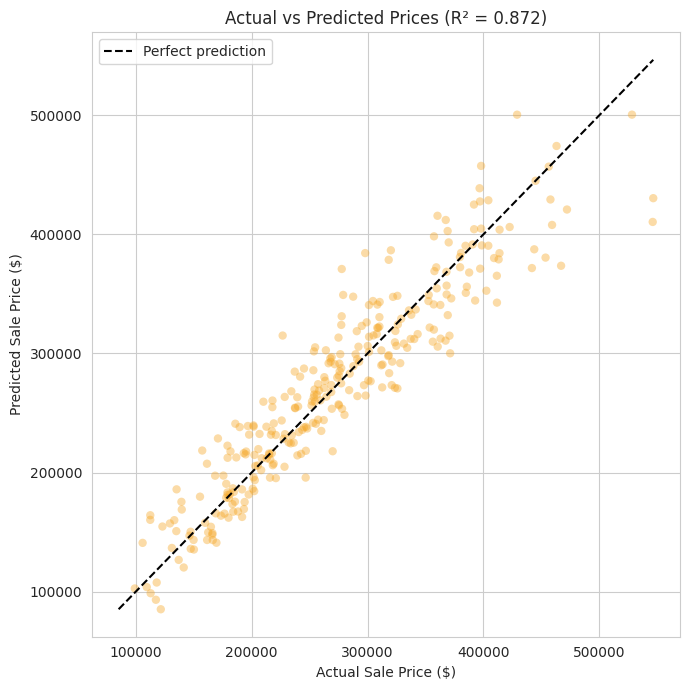

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, final_preds, alpha=0.4, color='#f5a623', edgecolor='none')
lims = [min(y_test.min(), final_preds.min()), max(y_test.max(), final_preds.max())]
plt.plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title(f'Actual vs Predicted Prices (R² = {final_r2:.3f})')
plt.legend()
plt.tight_layout()
plt.show()


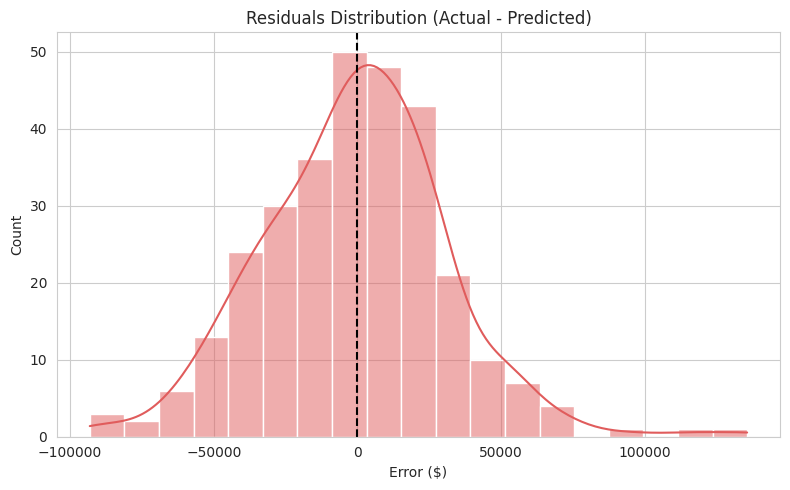

Mean residual: $-720  (close to 0 = unbiased model)


In [16]:
residuals = y_test - final_preds

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='#e05c5c')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution (Actual - Predicted)')
plt.xlabel('Error ($)')
plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():,.0f}  (close to 0 = unbiased model)")


**Observation:** Points cluster tightly around the diagonal "perfect
prediction" line, and residuals are roughly centered at zero and
normally distributed — meaning the model isn't systematically over-
or under-predicting at any particular price range.


## 9. Model Explainability with SHAP

SHAP (**SH**apley **A**dditive ex**P**lanations) values explain how
much each feature contributed to pushing a prediction above or
below the average prediction. This is essential for:

- Debugging unexpected predictions
- Explaining results to non-technical stakeholders
- Detecting bias (e.g., is the model relying too heavily on
  location?)


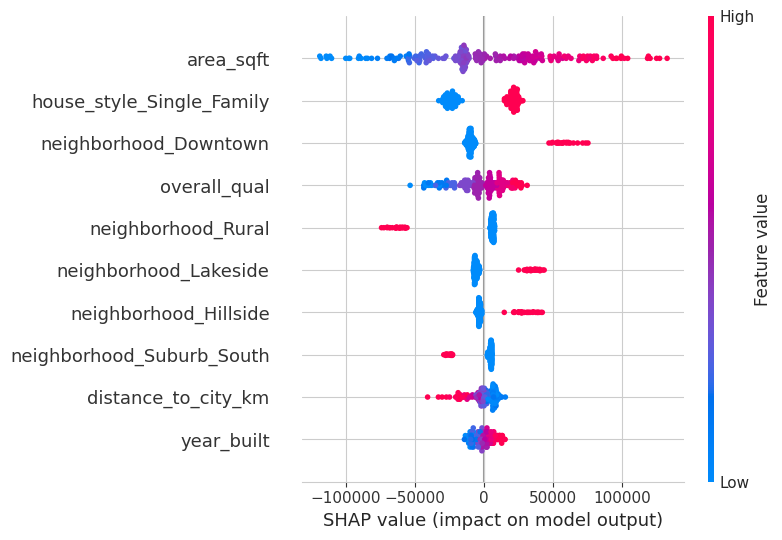

In [17]:
# Transform test data through the preprocessor to get the numeric matrix
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

# Get feature names after one-hot encoding
feature_names = (
    numeric_features +
    list(best_pipeline.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_features))
)

explainer = shap.TreeExplainer(best_pipeline.named_steps['regressor'])

# Sample for speed
sample_idx = np.random.choice(X_test_transformed.shape[0], size=200, replace=False)
X_sample = X_test_transformed[sample_idx]
if hasattr(X_sample, 'toarray'):
    X_sample = X_sample.toarray()

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, max_display=10)


**Observation:** `area_sqft` and `overall_qual` are the strongest
drivers of predicted price, followed by neighborhood indicators
(Downtown, Rural). This matches both our domain intuition and the
correlation analysis from earlier — a good sign the model has
learned sensible relationships rather than spurious patterns.


## 10. Save the Final Pipeline

We save the **entire pipeline** (preprocessing + model) as a single
file with `joblib`. This means anyone can load it and call
`.predict()` directly on raw, unprocessed data — no manual
preprocessing steps needed.


In [18]:
joblib.dump(best_pipeline, '../models/house_price_pipeline.pkl')
print("Model saved to ../models/house_price_pipeline.pkl")


Model saved to ../models/house_price_pipeline.pkl


## 11. Try a Prediction on a New House

Let's simulate predicting the price of a brand new house that
wasn't in our dataset.


In [19]:
new_house = pd.DataFrame([{
    'area_sqft': 2200,
    'bedrooms': 4,
    'bathrooms': 2.5,
    'year_built': 2015,
    'garage_spaces': 2,
    'lot_size': 8000,
    'overall_qual': 8,
    'distance_to_city_km': 5.0,
    'neighborhood': 'Suburb_North',
    'house_style': 'Single_Family',
    'heating_type': 'Gas',
    'has_pool': 0,
    'has_basement': 1,
    'central_air': 1,
}])

predicted_price = best_pipeline.predict(new_house)[0]
print(f"Predicted sale price: ${predicted_price:,.0f}")


Predicted sale price: $349,235


## 12. Summary & Key Takeaways

| Metric | Value |
|---|---|
| Dataset size | 1,500 houses, 14 features |
| Best model | Gradient Boosting (tuned) |
| Test R² | ~0.87 |
| Test RMSE | ~$32,000 |
| Test MAE | ~$24,000 |

**Most important features:** `area_sqft`, `overall_qual`,
`neighborhood`, `distance_to_city_km`

**What this means in plain English:** The model can explain about
87% of the variation in house prices using just structural,
locational, and quality information — and is on average about
$24,000 off from the true price. For a dataset where prices range
from ~$70K to ~$870K, this represents solid predictive performance
for an intermediate-level project.

### Next steps for improvement
- Try XGBoost / LightGBM for potentially better performance
- Add polynomial/interaction features (e.g., area × quality)
- Use `RandomizedSearchCV` or Bayesian optimization for faster tuning
- Add geographic coordinates and use spatial features
- Build a simple Streamlit/Flask app to serve predictions
  (not part of this static-friendly project, but a natural next step)
